# FullRCNNModel Quantization — Lab Notebook

**Goal.** Quantize the reference architecture's real `FullRCNNModel` surface-code decoder (d=5, r=3, p=0.010)
toward FPGA deployment via hls4ml (collaborator: Giuseppe). Path B = Quantization-Aware
Training with QKeras `quantized_bits` applied at point-of-use inside the custom `call()`
methods (standard QDense substitution can't reach the reference architecture's hand-managed `add_weight`
tensors). `CNNModel.py` stays byte-for-byte pristine; all quantization lives in
`CNNModel_quantized.py`.

This notebook is **live**: cells load the result files from disk and rebuild every number. The authoritative ledger is `docs/RUN_LOG.md`; this is the runnable view.

> Run on EAF (`.venv/bin/python` kernel) where `~/rcnn_threshold/` lives.

## Fixed substrate (never regenerate)

| item | value |
|---|---|
| architecture | `FullRCNNModel('ZL', d=5, k=3, r=3, [100,100], npol=2)`, ~51.5k params |
| train pool | `data_d5_p0.010_r3.npz` (10.01M shots, **gen-seed 42**) |
| eval tail (all phases) | `data_d5_p0.010_r3_TAIL200k.npz` (200k, **gen-seed 43**, disjoint) |
| quantizer (weights) | `quantized_bits(B, 1)` = 1 sign + 1 int + (B−2) frac |
| env | EAF, `.venv` qkeras 0.9.0, TF 2.15.1, Keras 2.15.0; A100 MIG 3g.40gb |

Contamination fix: the old 200k tail overlapped the 10M train set by 190k shots
(~+0.0016 p_L optimism). Replaced by a fresh gen-seed-43 tail (`make_fresh_tail.py`).

In [1]:
import os, glob, json
import numpy as np, pandas as pd
# Locate rcnn_threshold/ without depending on the working directory. Jupyter sets the CWD to the
# notebook's OWN folder, so a bare './rcnn_threshold' test only works for a notebook sitting at the
# repo root -- from analysis_notebooks/ it silently missed and fell through to ~/rcnn_threshold,
# which on a laptop holds only pools/ and none of the out_q* result dirs. Walk up instead, then
# fall back to $HOME (the EAF layout, where the results really do live under the home directory).
def _find_base():
    d = os.path.abspath(os.getcwd())
    while True:
        cand = os.path.join(d, 'rcnn_threshold')
        if os.path.isdir(cand):
            return cand
        parent = os.path.dirname(d)
        if parent == d:                       # hit the filesystem root
            return os.path.expanduser('~/rcnn_threshold')
        d = parent

BASE = _find_base()
OUT_Q  = os.path.join(BASE, 'out_q')           # Step-2 Pareto CSVs
OUT_MC = os.path.join(BASE, 'out_q_mcnemar')   # Phase 1 McNemar + Phase 3 JSON
OUT_2A = os.path.join(BASE, 'out_q_phase2a')   # Phase 2a activation sweep + its paired tests
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 40)
print('BASE :', BASE)
print('out_q     :', OUT_Q, '->', len(glob.glob(OUT_Q+'/*.csv')), 'csv')
print('out_q_mcnemar:', OUT_MC, '->', sorted(os.path.basename(f) for f in glob.glob(OUT_MC+'/*'))[:6])
print('out_q_phase2a:', OUT_2A, '->', len(glob.glob(OUT_2A+'/*.csv')), 'csv')

# The ONE true MWPM on the fresh 200k tail. Verified 2026-07-20 by reading the code, not the
# comment: eval_on_tail.py --mcnemar decodes these exact shots with PyMatching and overwrites the
# looked-up value. The sweep CSVs' mwpm_p_L column (0.0451) and the 0.0518 seen elsewhere both come
# from train_one.lookup_mwpm(), keyed only on (d, p, rounds) -- it does not know which tail it is
# being asked about. Never read the baseline out of a sweep CSV column.
MWPM_FRESH_TAIL = 0.049405

BASE : /Users/karriechey/Documents/FNAL-QCDecoding-FPGA/rcnn_threshold
out_q     : /Users/karriechey/Documents/FNAL-QCDecoding-FPGA/rcnn_threshold/out_q -> 16 csv
out_q_mcnemar: /Users/karriechey/Documents/FNAL-QCDecoding-FPGA/rcnn_threshold/out_q_mcnemar -> ['mcnemar_knee.csv', 'profile_ranges_w6.json', 'profile_ranges_w6_seed0.json', 'profile_ranges_w6_seed1.json', 'profile_ranges_w6_seed2.json', 'rcnn_d5_p0.010_r3_w6_seed0_ntr10000000.csv']
out_q_phase2a: /Users/karriechey/Documents/FNAL-QCDecoding-FPGA/rcnn_threshold/out_q_phase2a -> 13 csv


## Phase 0 — implementation + local gates (DONE)

- Path B re-homed into `CNNModel_quantized.py`; `CNNModel.py` pristine (monkeypatch
  point-of-use quantizers on the custom layers).
- Gates passed: None-path == original (max|diff|=0); quantization bites; grads on 35
  quantized vars; FP32 10M weights load into a None-model bit-exact (prob corr 1.0).

## Step 2 — weight-bit-width Pareto (DONE, n=3)

`sweep_quantized.py` × {8,6,4,3,2} bits × {0,1,2} seeds at 10M shots, fresh 200k tail.
FP32 anchor reuses existing 10M weights (no retrain). Collate below.

In [2]:
# Rebuild the Pareto table from the per-run CSVs + fp32 anchor
rows = [pd.read_csv(f) for f in sorted(glob.glob(OUT_Q+'/rcnn_d5_p0.010_r3_w*_seed*_ntr*.csv'))]
fp32 = os.path.join(OUT_Q, 'fp32_anchor.csv')
mwpm = None
if os.path.exists(fp32):
    fa = pd.read_csv(fp32).drop_duplicates('weights', keep='last')
    npar = int(rows[0]['n_params'].iloc[0]) if rows else np.nan
    for _, x in fa.iterrows():
        sd = int(str(x['weights']).split('seed')[1].split('_')[0])
        rows.append(pd.DataFrame([dict(weight_bits=32, seed=sd, p_L=float(x['p_L']),
                    n_params=npar, n_test=int(x['n_test']))]))
    m = pd.to_numeric(fa['mwpm_p_L'], errors='coerce').dropna()
    mwpm = float(m.mean()) if len(m) else None
df = pd.concat(rows, ignore_index=True).drop_duplicates(['weight_bits','seed'], keep='last')
g = df.groupby('weight_bits')['p_L'].agg(['mean','std','count'])
g['size_KB'] = g.index * int(df['n_params'].dropna().iloc[0]) / 8 / 1024
g['xMWPM'] = g['mean']/mwpm if mwpm else np.nan
print('MWPM (fresh tail) =', mwpm)
g.sort_values('size_KB')

MWPM (fresh tail) = 0.049405


,mean,std,count,size_KB,xMWPM
weight_bits,,,,,
2,0.127965,0.012209,3,12.584717,2.590122
3,0.061162,0.002790,3,18.877075,1.237965
4,0.054637,0.002415,3,25.169434,1.105893
6,0.047182,0.000516,3,37.754150,0.954998
8,0.045945,0.000422,3,50.338867,0.929967
32,0.046145,0.000536,3,201.355469,0.934015


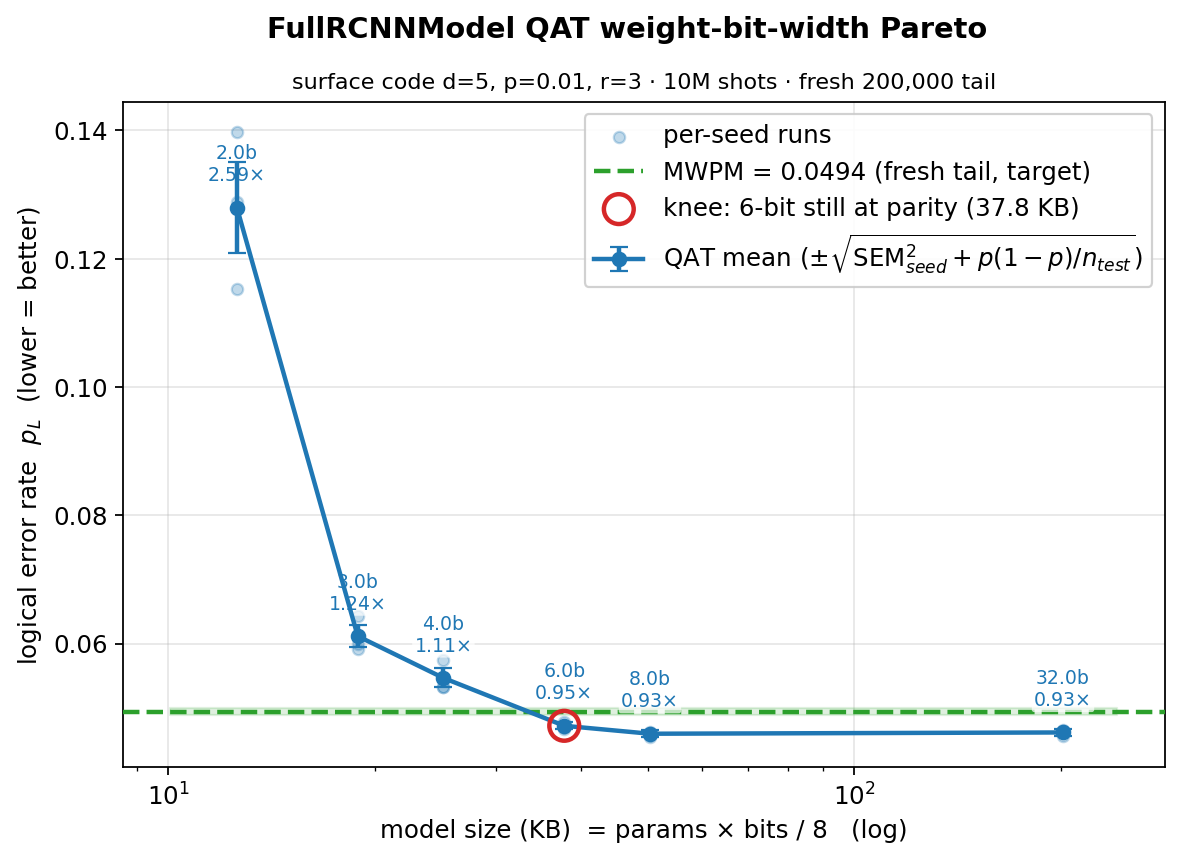

In [3]:
# The Pareto plot -- search known locations (repo snapshot / figures / EAF-style plots/)
from IPython.display import Image
cands = ['analysis_notebooks/figures/pareto_clean.png',
         'experiment_log/plots/pareto_frontier.png',
         'experiment_log/results_snapshot/eaf/QuantumDecoderQKeras/plots/rcnn_d5_r3_qat_pareto.png',
         'plots/rcnn_d5_r3_qat_pareto.png']
p = next((x for x in cands if os.path.exists(x)), None)
Image(p) if p else print('pareto plot not found in repo; regenerate with collate_pareto.py --out-dir', OUT_Q)

**Headline.** 8-bit lossless (= FP32); **6-bit is the knee** (37.8 KB, 5.3× smaller,
beats MWPM). Sharp cliff 6→4 (4-bit ~3.4σ worse); 2-bit collapses. Variance blows up at
low bits. This is the **weights-only** ceiling, activations still FP32.

## Phase 1 — paired McNemar at the knee (DONE)

`phase1_mcnemar.py` retrained {6,8} × {0,1,2} with `--save-weights` into `out_q_mcnemar/`
(no clobber of the Pareto CSVs), then `eval_on_tail.py --mcnemar` on the shared fresh tail.
The paired test licenses "beats MWPM" with discordant shot counts, not error-bar overlap.

In [4]:
mc = pd.read_csv(os.path.join(OUT_MC,'mcnemar_knee.csv')).drop_duplicates('weights', keep='last')
mc['bits'] = mc['weights'].str.extract(r'_w(\d+)_').astype(int)
mc['seed'] = mc['weights'].str.extract(r'seed(\d+)_').astype(int)
show = mc[['bits','seed','p_L','mwpm_p_L','ratio','rcnn_only','mwpm_only','net_rcnn_wins','p_exact']]
show.sort_values(['bits','seed']).reset_index(drop=True)

,bits,seed,p_L,mwpm_p_L,ratio,rcnn_only,mwpm_only,net_rcnn_wins,p_exact
0,6,0,0.046675,0.049405,0.9447,3619,3073,546,2.631893e-11
1,6,1,0.047715,0.049405,0.9658,3625,3287,338,5.029868e-05
2,6,2,0.045580,0.049405,0.9226,3696,2931,765,5.703392e-21
3,8,0,0.046060,0.049405,0.9323,3658,2989,669,2.399718e-16
4,8,1,0.045645,0.049405,0.9239,3673,2921,752,2.077086e-20
5,8,2,0.046595,0.049405,0.9431,3683,3121,562,1.011172e-11


saved -> ./figures/mcnemar_knee.png


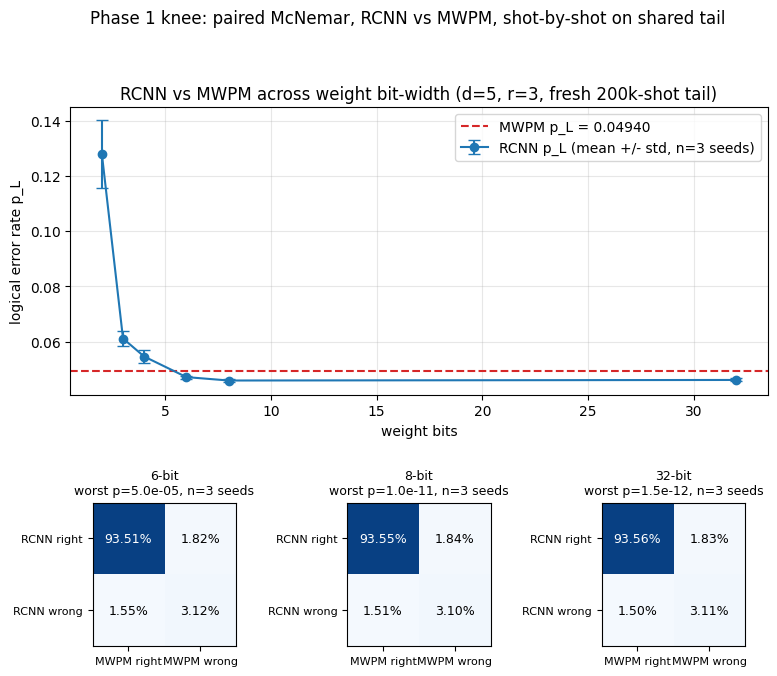

In [5]:
import matplotlib.pyplot as plt

# combine bits=32 (fp32 anchor, already has a McNemar row from the sweep's anchor step)
# with bits=6,8 (this phase) into one table so the figure covers the whole knee
mc_all = pd.concat([
    fa.assign(bits=32, seed=fa['weights'].str.extract(r'seed(\d+)_')[0].astype(int)),
    mc,
], ignore_index=True).drop_duplicates(['bits', 'seed'], keep='last')

fig = plt.figure(figsize=(9, 7))
gs = fig.add_gridspec(2, 3, height_ratios=[2, 1], hspace=0.5, wspace=0.35)

# top: p_L vs bits, mean +/- std across seeds, MWPM reference line
ax0 = fig.add_subplot(gs[0, :])
ax0.errorbar(g.index, g['mean'], yerr=g['std'], marker='o', capsize=4,
             color='tab:blue', label='RCNN p_L (mean +/- std, n=3 seeds)')
if mwpm:
    ax0.axhline(mwpm, color='tab:red', ls='--', label=f'MWPM p_L = {mwpm:.5f}')
ax0.set_xlabel('weight bits'); ax0.set_ylabel('logical error rate p_L')
ax0.set_title('RCNN vs MWPM across weight bit-width (d=5, r=3, fresh 200k-shot tail)')
ax0.legend(); ax0.grid(alpha=0.3)

# bottom: 2x2 McNemar contingency per bit-width, seed-averaged, fraction of n_test
for i, b in enumerate(sorted(mc_all['bits'].unique())):
    ax = fig.add_subplot(gs[1, i])
    sub = mc_all[mc_all['bits'] == b]
    nte = sub['n_test'].iloc[0]
    table = np.array([[sub['both_right'].mean(), sub['rcnn_only'].mean()],
                       [sub['mwpm_only'].mean(), sub['both_wrong'].mean()]]) / nte
    ax.imshow(table, cmap='Blues', vmin=0, vmax=1)
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f'{table[r, c]*100:.2f}%', ha='center', va='center',
                    color='white' if table[r, c] > 0.5 else 'black', fontsize=9)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['MWPM right', 'MWPM wrong'], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['RCNN right', 'RCNN wrong'], fontsize=8)
    p_worst = sub['p_exact'].max()  # worst (least significant) seed at this bit-width
    ax.set_title(f'{b}-bit\nworst p={p_worst:.1e}, n={len(sub)} seeds', fontsize=9)

fig.suptitle('Phase 1 knee: paired McNemar, RCNN vs MWPM, shot-by-shot on shared tail', y=1.02)
out_png = './figures/mcnemar_knee.png'
os.makedirs(os.path.dirname(out_png), exist_ok=True)
fig.savefig(out_png, dpi=150, bbox_inches='tight')
print('saved ->', out_png)
plt.show()

**Result.** Every seed × every bit-width **beats** MWPM, paired-significant (worst
p=5e-5 at w6/seed1). Claim upgrades from "6-bit at parity" to **"6-bit weights beat MWPM,
paired-significant."** Scope: weights-only, activations FP32, r=3.

## Phase 2 — activation quantization (DESIGN FROZEN, verified vs source)

Taxonomy-driven, **per-class** integer bits (a single global activation width is ill-posed:
z-like at B=4 has negative fractional width). All `[V]` items verified against
`CNNModel.py` / `utilities_arrayops.py`:

| class | source fact | quantizer | I | swept width |
|---|---|---|---|---|
| z-like | `bound_zlike=12` | signed | 4 (analytic) | B_z ∈ {10,8,6} |
| p/f-like | `frac=sigmoid` | unsigned | 0 | B_b ∈ {8,6,4} |
| cφ/α-like | `phase=tanh` | signed | 1 | B_b ∈ {8,6,4} |
| relu hidden | `Dense(relu)×2` | quantized_relu | profiled | B_d ∈ {8,6} |
| **x-like** | `clip_exp=[6e-6,1.6e5]` (~10 decades) | **none — Phase 4** | — | z-domain LSE / HLS LUT |

Key source findings: combiner `phase=2·tanh` is **signed**, so the log-domain combination
can go ≤0 (rescued by `clip_exp` before `log`). This makes *plain* LSE unavailable — the
Phase-4 remedy is a **choice** (signed-LSE OR constrain c_φ to PSD via a Gram
parameterization; the latter needs retraining), NOT decided here.
Clip is applied to the **sum output** → quantize AFTER the clip. inverter/pow dormant at
r=3. Anchor for Phase 2 = **w6/act-FP32** (not FP32/FP32).

### Per-class fixed-point format (methodology reference)

Activation quantization is **per-class, not one global format**. Each class has a FIXED integer
width `I`; the fractional width follows from the swept word length `B`. This is the table for the
paper's methodology section.

| class | signed? | integer I | what it is |
|---|---|---|---|
| **zlike** | signed | 4 | combiner output / decoder input (±12 clip) |
| **relu** | unsigned | 6 (abs-max) | decoder hidden-ReLU outputs |
| **embed** | signed | 2 | Detector{Bit,Event} embedder output |
| **cphi** | signed | 0 | c_φ = tanh in (−1,1) |
| **pf** | unsigned | 0 | sigmoid fractions in (0,1) |

Fractional bits depend on the word length **B**: `frac = B − I − 1` for the signed classes
(`quantized_bits`, one bit spent on sign), `frac = B − I` for the unsigned ReLU (`quantized_relu`).

- **B=8** (free): zlike ap_fixed<8,5> frac=3 · relu ap_ufixed<8,6> frac=2 · embed frac=5 ·
  cphi frac=7 · pf frac=8.
- **B=6** (the knee, small cost): zlike frac=1 · relu frac=**0** · embed frac=3 · cphi frac=5 ·
  pf frac=6.
- **B=4** (infeasible — collapses): zlike frac=**−1**, relu frac=**−2** — negative fractional
  width, which is why B=4 dies (base-rate constant predictor).
- **relu retune** (Phase 2a-ReLU): at relu **I=5** the ReLU becomes ap_ufixed<6,5> frac=1 at B=6.

The **x-like** tensors are deliberately **not** quantized — left FP32 for Phase 4 (they span
~10 decades; no sane fixed-point format).

**Two conventions to keep straight.** (1) QKeras `integer` **excludes** the sign bit, so a signed
class with integer I maps to `ap_fixed<B, I+1>` in the paper's sign-inclusive notation. (2) Weights
are separate: `quantized_bits(B, 1)` = 1 sign + 1 integer + (B−2) frac.

In [6]:
# Live derivation of the per-class format table straight from ActQuant._CLASSES, so the
# methodology table above can never silently drift from the code. Imports the quantization module
# (pulls in qkeras/TF -- one-time cost per kernel). ap_fixed uses the paper's SIGN-INCLUSIVE
# integer field (I + sign); QKeras' own `integer` arg excludes the sign, hence the +sign here.
from CNNModel_quantized import ActQuant

def fmt_row(cls, I, kneg, is_relu, B):
    sign = 1 if (kneg and not is_relu) else 0
    frac = B - I - sign                       # quantized_relu: sign=0 -> B-I; signed qb: B-I-1
    kind = 'ap_ufixed' if sign == 0 else 'ap_fixed'
    return f'{kind}<{B},{I + sign}>(frac={frac})', frac

rows = []
for cls, (I, kneg, is_relu) in sorted(ActQuant._CLASSES.items()):
    r = {'class': cls, 'I': I, 'signed': bool(kneg and not is_relu)}
    for B in (8, 6, 4):
        fs, fr = fmt_row(cls, I, kneg, is_relu, B)
        r[f'B={B}'] = fs
        r[f'frac@{B}'] = fr
    rows.append(r)
fmt = pd.DataFrame(rows).set_index('class')
print('Per-class fixed-point format, derived from ActQuant._CLASSES (frac<0 = infeasible):')
print(fmt[['I', 'signed', 'B=8', 'B=6', 'B=4']].to_string())
print('\\nfrac by B (negative = format collapses):')
print(fmt[['frac@8', 'frac@6', 'frac@4']].to_string())
print('\\nrelu retune (I=5) at B=6:', fmt_row('relu', 5, False, True, 6)[0])

Per-class fixed-point format, derived from ActQuant._CLASSES (frac<0 = infeasible):
       I  signed                     B=8                     B=6                      B=4
class                                                                                    
cphi   0    True   ap_fixed<8,1>(frac=7)   ap_fixed<6,1>(frac=5)    ap_fixed<4,1>(frac=3)
embed  2    True   ap_fixed<8,3>(frac=5)   ap_fixed<6,3>(frac=3)    ap_fixed<4,3>(frac=1)
pf     0   False  ap_ufixed<8,0>(frac=8)  ap_ufixed<6,0>(frac=6)   ap_ufixed<4,0>(frac=4)
relu   6   False  ap_ufixed<8,6>(frac=2)  ap_ufixed<6,6>(frac=0)  ap_ufixed<4,6>(frac=-2)
zlike  4    True   ap_fixed<8,5>(frac=3)   ap_fixed<6,5>(frac=1)   ap_fixed<4,5>(frac=-1)
\nfrac by B (negative = format collapses):
       frac@8  frac@6  frac@4
class                        
cphi        7       5       3
embed       5       3       1
pf          8       6       4
relu        2       0      -2
zlike       3       1      -1
\nrelu retune (I=5) at B=6: ap_uf

## Phase 3 — range profiling (per-seed, for the ap_fixed table)

`profile_ranges.py` wraps (never reimplements) the layer `.call`s + `clip_zlike/clip_exp`,
per instance, and reproduces the sweep p_L as a wrap-integrity check. Load the per-seed
JSONs and check whether `implied_I` is stable across seeds (a fixed_point_format_table caveat if not).

In [7]:
js = sorted(glob.glob(OUT_MC+'/profile_ranges_w6_seed*.json'))
print('profile JSONs:', [os.path.basename(x) for x in js])
def load(f):
    d = json.load(open(f))
    prov = d.get('_provenance', {})
    return d, prov
if js:
    d0, prov0 = load(js[0])
    print('seed', prov0.get('seed'), 'profiled p_L =', prov0.get('profiled_p_L'),
          'expected', prov0.get('expected_p_L'))
    # combination_preclip = the LSE-decision sites
    comb = {k:v for k,v in d0.items() if k.startswith('combination_preclip')}
    for k,v in comb.items():
        print(f"{k}: val[{v['min']:.3g},{v['max']:.3g}] frac_nonpos={v.get('frac_nonpositive',0):.2%}")
else:
    print('run profile_ranges.py for seed0/1/2 first (see cell below)')

profile JSONs: ['profile_ranges_w6_seed0.json', 'profile_ranges_w6_seed1.json', 'profile_ranges_w6_seed2.json']
seed 0 profiled p_L = 0.046675 expected 0.046675
combination_preclip@CNNModel.py:1896#CNNStateCorrelator#0: val[6.52e-09,215] frac_nonpos=0.00%
combination_preclip@CNNModel.py:1896#CNNStateCorrelator#1: val[2.01e-07,158] frac_nonpos=0.00%
combination_preclip@CNNModel.py:1896#CNNStateCorrelator#2: val[6.61e-08,2.74e+03] frac_nonpos=0.00%
combination_preclip@CNNModel.py:1896#CNNStateCorrelator#3: val[-2.98e-08,4.31e+03] frac_nonpos=0.00%
combination_preclip@CNNModel.py:1896#CNNStateCorrelator#4: val[9.55e-11,119] frac_nonpos=0.00%
combination_preclip@CNNModel.py:1896#CNNStateCorrelator#5: val[-8.17,1.38e+03] frac_nonpos=9.41%
combination_preclip@CNNModel.py:1896#CNNStateCorrelator#6: val[-5.35,4.01e+04] frac_nonpos=10.61%
combination_preclip@CNNModel.py:1896#CNNStateCorrelator#7: val[-10.3,1.37e+03] frac_nonpos=4.61%
combination_preclip@CNNModel.py:1896#CNNStateCorrelator#8: va

In [8]:
# per-seed implied_I stability across sites (fills the fixed_point_format_table caveat)
if len(js) >= 2:
    recs = {}
    for f in js:
        d,_ = load(f); sd = json.load(open(f))['_provenance']['seed']
        for k,v in d.items():
            if isinstance(v, dict) and 'implied_I_from_max' in v:
                recs.setdefault(k, {})[f'seed{sd}_I'] = v['implied_I_from_max']
    tbl = pd.DataFrame(recs).T
    tbl['I_varies'] = tbl.nunique(axis=1) > 1
    display(tbl)
    print('sites where implied_I moves across seeds:', list(tbl.index[tbl['I_varies']]))
else:
    print('need >=2 seed JSONs to compare')

,seed0_I,seed1_I,seed2_I,I_varies
CNNKernelWithEmbedding#0_out,11,16,9,True
CNNKernelWithEmbedding#10_out,4,4,4,False
CNNKernelWithEmbedding#11_out,4,4,4,False
CNNKernelWithEmbedding#12_out,4,4,4,False
CNNKernelWithEmbedding#13_out,4,4,4,False
...,...,...,...,...
zlike_preclip@CNNModel.py:875#DetectorEventStateEmbedder#8,2,2,2,False
zlike_preclip@CNNModel.py:875#DetectorEventStateEmbedder#9,0,2,2,True
zlike_preclip@CNNModel_quantized.py:170#RCNNFinalStateKernelCombiner#0,1,1,1,False
zlike_preclip@CNNModel_quantized.py:170#RCNNInitialStateKernelCombiner#0,0,0,0,False


sites where implied_I moves across seeds: ['CNNKernelWithEmbedding#0_out', 'CNNKernelWithEmbedding#1_out', 'CNNKernelWithEmbedding#2_out', 'CNNKernelWithEmbedding#3_out', 'CNNKernelWithEmbedding#4_out', 'CNNKernelWithEmbedding#5_out', 'CNNKernelWithEmbedding#6_out', 'CNNKernelWithEmbedding#7_out', 'CNNStateCorrelator#0_out', 'CNNStateCorrelator#1_out', 'CNNStateCorrelator#2_out', 'CNNStateCorrelator#3_out', 'CNNStateCorrelator#4_out', 'CNNStateCorrelator#5_out', 'CNNStateCorrelator#6_out', 'CNNStateCorrelator#7_out', 'CNNStateCorrelator#8_out', 'CNNStateCorrelator#9_out', 'DetectorEventStateEmbedder#10_out', 'DetectorEventStateEmbedder#11_out', 'DetectorEventStateEmbedder#13_out', 'DetectorEventStateEmbedder#1_out', 'DetectorEventStateEmbedder#4_out', 'DetectorEventStateEmbedder#6_out', 'DetectorEventStateEmbedder#8_out', 'DetectorEventStateEmbedder#9_out', 'RCNNInitialStateKernelCombiner#0_out', 'RCNNLeadInKernelCombiner#0_out', 'combination_preclip@CNNModel.py:1896#CNNStateCorrelator

### To rerun Phase 3 (per seed, asserts p_L)

```bash
cd ~/QuantumDecoderQKeras
.venv/bin/python profile_ranges.py --weights ~/rcnn_threshold/out_q_mcnemar/rcnn_d5_p0.010_r3_w6_seed0_ntr10000000.weights.h5 --expect-pl 0.046675
.venv/bin/python profile_ranges.py --weights ~/rcnn_threshold/out_q_mcnemar/rcnn_d5_p0.010_r3_w6_seed1_ntr10000000.weights.h5 --expect-pl 0.047715
.venv/bin/python profile_ranges.py --weights ~/rcnn_threshold/out_q_mcnemar/rcnn_d5_p0.010_r3_w6_seed2_ntr10000000.weights.h5 --expect-pl 0.045580
```

## Phase 2a — activation-precision sweep (DONE, n=3)

Weights fixed at 6 bits (the Phase-1 knee); activation word length **B swept over {32, 8, 6, 4}**,
3 seeds, 10M training shots, fresh disjoint 200k tail. `B=32` means activation quantization OFF —
it is the per-seed **control**, and it must reproduce the Phase-1 w6/act-FP32 anchor.

Driver `phase2a_sweep.py` (fanned across 3 EAF pods) → `phase2a_collate.py` (tables + figure) →
`phase2a_mcnemar.py` (the paired tests).

### Prerequisite: the determinism fix

The first control reruns spiked on seeds 1 and 2 — val_loss jumping to 0.18 / 0.37 around epoch 3,
landing p_L ~0.050 / 0.057 against anchors of ~0.047 / 0.046 — on identical code, seed and recipe
to Phase 1. Diagnosed by elimination:

- **not the recipe** — 100k runs were smooth on both Mac-CPU and EAF-GPU;
- **not the TF version** — the spiking sweep logged TF 2.15.1, same as the anchor (the bare EAF
  shell's TF 2.16.2 / Keras 3 was never what the sweep used);
- **not the device** — both CPU and GPU were smooth at 100k;
- **scale** was the only variable left: 10M shots is ~1000 steps/epoch vs 8 at 100k, so ~125× more
  chances for one bad step under the reference architecture's high early LR (0.01). 100k structurally cannot reproduce it.

Confirmed by rerunning seed 2 at 10M with the flags on: smooth, no epoch-3 spike. **Cause =
nondeterministic GPU/cuDNN floating-point reduction order, amplified at scale**; the Phase-1 anchor
had simply drawn three spike-free runs. `TF_DETERMINISTIC_OPS=1` + `TF_CUDNN_DETERMINISTIC=1` are
now set in `train_one_quantized.py` *before* `import tensorflow`, with a hard
`assert tf.__version__.startswith('2.15')` guard.

`clipnorm=1.0` was tried during the diagnosis and **reverted** — it suppressed the symptom, left
the cause in place, and would have split this recipe from the Phase-1 anchor's.

In [9]:
# Control gate: each B=32 control must reproduce its Phase-1 anchor (w6 / float activations).
ANCHOR = {0: 0.046675, 1: 0.047715, 2: 0.045580}   # from out_q_mcnemar/mcnemar_knee.csv, w6 rows

def load_2a():
    """{(act_bits, seed): p_L} from the Phase-2a per-run CSVs."""
    out = {}
    for f in glob.glob(os.path.join(OUT_2A, '*_ntr10000000.csv')):
        r = pd.read_csv(f).iloc[0]
        out[(int(r['act_bits']), int(r['seed']))] = float(r['p_L'])
    return out

d2a = load_2a()
gate = pd.DataFrame([
    {'seed': s, 'control_B32': d2a.get((32, s)), 'phase1_anchor': ANCHOR[s],
     'delta': (d2a.get((32, s)) - ANCHOR[s]) if d2a.get((32, s)) is not None else None}
    for s in sorted({s for (_, s) in d2a})])
print('Control gate -- all three reproduce the anchor (seed 2 was 0.05685 on the spiked run):')
print(gate.to_string(index=False))

Control gate -- all three reproduce the anchor (seed 2 was 0.05685 on the spiked run):
 seed  control_B32  phase1_anchor     delta
    0     0.046590       0.046675 -0.000085
    1     0.047310       0.047715 -0.000405
    2     0.046565       0.045580  0.000985


In [10]:
# (1) p_L by activation width, and (2) the WITHIN-SEED cost: p_L(B) - p_L(that seed's control).
# Within-seed differencing cancels each seed's own convergence level. NOTE this is DESCRIPTIVE
# only -- the significance test is McNemar, below, and it does not agree with the naive reading.
bits = sorted({b for (b, _) in d2a}, reverse=True)
seeds = sorted({s for (_, s) in d2a})

tbl = pd.DataFrame({f'seed{s}': [d2a.get((b, s)) for b in bits] for s in seeds}, index=bits)
tbl.index.name = 'B'
tbl['mean'] = tbl.mean(axis=1)
tbl['xMWPM'] = tbl['mean'] / MWPM_FRESH_TAIL
print('(1) p_L by activation word length B  (B=32 = control, activations off)')
print(tbl.round(5).to_string(), '\n')

delta = pd.DataFrame({f'seed{s}': [(d2a.get((b, s)) - d2a[(32, s)]) if d2a.get((b, s)) is not None
                                   else None for b in bits] for s in seeds}, index=bits)
delta.index.name = 'B'
delta['mean_delta'] = delta.mean(axis=1)
print('(2) within-seed cost: p_L(B) - p_L(control)')
print(delta.round(5).to_string())

(1) p_L by activation word length B  (B=32 = control, activations off)
      seed0    seed1    seed2     mean    xMWPM
B                                              
32  0.04659  0.04731  0.04656  0.04682  0.94771
8   0.04856  0.04629  0.04714  0.04733  0.95803
6   0.04801  0.04936  0.04770  0.04836  0.97881
4   0.28260  0.28260  0.28260  0.28260  5.72007 

(2) within-seed cost: p_L(B) - p_L(control)
      seed0    seed1    seed2  mean_delta
B                                        
32  0.00000  0.00000  0.00000     0.00000
8   0.00197 -0.00102  0.00057     0.00051
6   0.00142  0.00205  0.00114     0.00154
4   0.23601  0.23529  0.23604     0.23578


### B=4 is an infeasible fixed-point format, **not** a measured precision limit

All three B=4 seeds returned **p_L = 0.28260 — exactly the tail's base rate** — with val_loss
pinned at 0.5935 from epoch 1. The model emitted a constant and never trained.

The cause is arithmetic, not accuracy. The per-class integer widths leave **negative fractional
width** at B=4 (fractional bits = B − I − sign):

| class | I | signed | frac @ B=4 | frac @ B=6 | frac @ B=8 |
|---|---|---|---|---|---|
| z-like | 4 | yes | **−1** | 1 | 3 |
| relu (decoder hidden) | 6 | no | **−2** | **0** | 2 |
| embed | 2 | yes | 1 | 3 | 5 |
| cφ | 0 | yes | 3 | 5 | 7 |
| p/f | 0 | no | 4 | 6 | 8 |

A negative fractional width means the representable values are spaced **more than 1.0 apart** —
at frac = −2 the ReLU grid is multiples of 4 across [0, 64), so every hidden activation below 2.0
rounds to zero. The network is destroyed before training starts, and **QKeras does not raise** on
this; it silently returns a garbage quantizer.

**So report the integer-width floor, not "4-bit activations fail."** Under the current policy the
minimum viable B is 6. Going lower requires retuning the integer widths first: the p99.9 ReLU width
(I=4) unlocks B=5, but z-like's I=4 follows from the architecture's own ±12 clip and is not
reducible without changing that bound.

`ActQuant.set_bits()` now **refuses** any configuration with negative fractional width, naming the
offending classes and the minimum viable B, and prints the resulting per-class `ap_fixed` format on
every run. The threshold is `frac < 0`, not `frac < 1`: **B=6 leaves the ReLU at frac = 0**
(resolution 1.0 on a [0,64) tensor) **and trained normally**, costing only ~+0.0015 — so zero
fractional width is warned about, not rejected. That B=6 works at all with an integer-only ReLU
grid is a robustness result in its own right.

### Paired McNemar
The within-seed p_L differences above are **not** a significance test. Both runs decode the **same
200k shots**, so each shot is a matched pair and the informative quantity is the discordant count
(shots where exactly one of the two is right) — the same convention as Phase 1.

Aggregate differencing called B=8 "noise" (deltas straddling zero, non-monotonic against B=6).
The paired test disagrees, and changes the conclusion.

In [11]:
# Paired tests: each quantized run vs its OWN seed's control, and vs MWPM, on the same shots.
# Produced by phase2a_mcnemar.py, which rebuilds each checkpoint WITH its activation quantizers
# (eval_on_tail.py has no activation support and would score these models with float activations).
f2a = os.path.join(OUT_2A, 'phase2a_mcnemar.csv')
if os.path.exists(f2a):
    mc2 = pd.read_csv(f2a).sort_values(['act_bits', 'seed'], ascending=[False, True])
    print('vs own control (net<0 = control wins):')
    print(mc2[['act_bits','seed','p_L','control_p_L','delta_vs_control',
               'ctrl_n_discordant','ctrl_p_exact']].to_string(index=False), '\n')
    print('vs MWPM (net>0 = RCNN wins):')
    mc2['net_vs_mwpm'] = mc2['mwpm_q_only'] - mc2['mwpm_mwpm_only']
    print(mc2[['act_bits','seed','p_L','mwpm_p_L','net_vs_mwpm',
               'mwpm_n_discordant','mwpm_p_exact']].to_string(index=False))
else:
    print('phase2a_mcnemar.csv not found -- regenerate with:')
    print('  python phase2a_mcnemar.py --dir', OUT_2A,
          '--pool <pools>/data_d5_p0.010_r3_TAIL200k.npz --acts 8,6 --seeds 0,1,2 \\')
    print('    --out-csv', f2a)

vs own control (net<0 = control wins):
 act_bits  seed      p_L  control_p_L  delta_vs_control  ctrl_n_discordant  ctrl_p_exact
        8     0 0.048570     0.046590          0.001980               5112  3.252429e-08
        8     1 0.046290     0.047310         -0.001020               4710  3.093207e-03
        8     2 0.047140     0.046565          0.000575               4895  1.032180e-01
        6     0 0.048045     0.046590          0.001455               5077  4.680349e-05
        6     1 0.049400     0.047310          0.002090               5374  1.261984e-08
        6     2 0.047650     0.046565          0.001085               4527  1.323330e-03 

vs MWPM (net>0 = RCNN wins):
 act_bits  seed      p_L  mwpm_p_L  net_vs_mwpm  mwpm_n_discordant  mwpm_p_exact
        8     0 0.048570  0.049405          167               7253  5.126789e-02
        8     1 0.046290  0.049405          623               6923  7.403795e-14
        8     2 0.047140  0.049405          453               69

**B=8 — no *systematic* cost, but not because the differences are noise.**
Two of the three seeds are individually significant **in opposite directions**: seed 0 favours the
control (p = 3.3e-08), seed 1 favours B=8 (p = 3.1e-03), seed 2 is not significant (p = 0.10). A
real per-run difference whose *sign flips across seeds* is training-run variation, not a precision
penalty. The defensible claim is "no consistent cost at B=8", **supported by the sign flip** —
not "the difference is within noise."

**B=6 — a real, consistent cost of about +0.0015.** All three seeds favour the control, all three
are significant, and the magnitudes agree (+0.0011 to +0.0021).

**Versus MWPM the margin becomes width-dependent.** At B=8 every seed beats MWPM. At B=6, seeds 0
and 2 still beat it (p = 1.3e-03, 2.7e-05) but **seed 1 lands at p_L = 0.049400 against MWPM's
0.049405 — a net of one shot in 200k, a dead heat.** So *"6-bit weights AND 6-bit activations still
beat MWPM"* is **not supportable as stated**; it holds at B=8 on all three seeds.

PS: The three seeds share one 200k tail, so their tests are **correlated, not independent**. Read
them as three consistent (or inconsistent) readings; do **not** Fisher-combine the p-values.

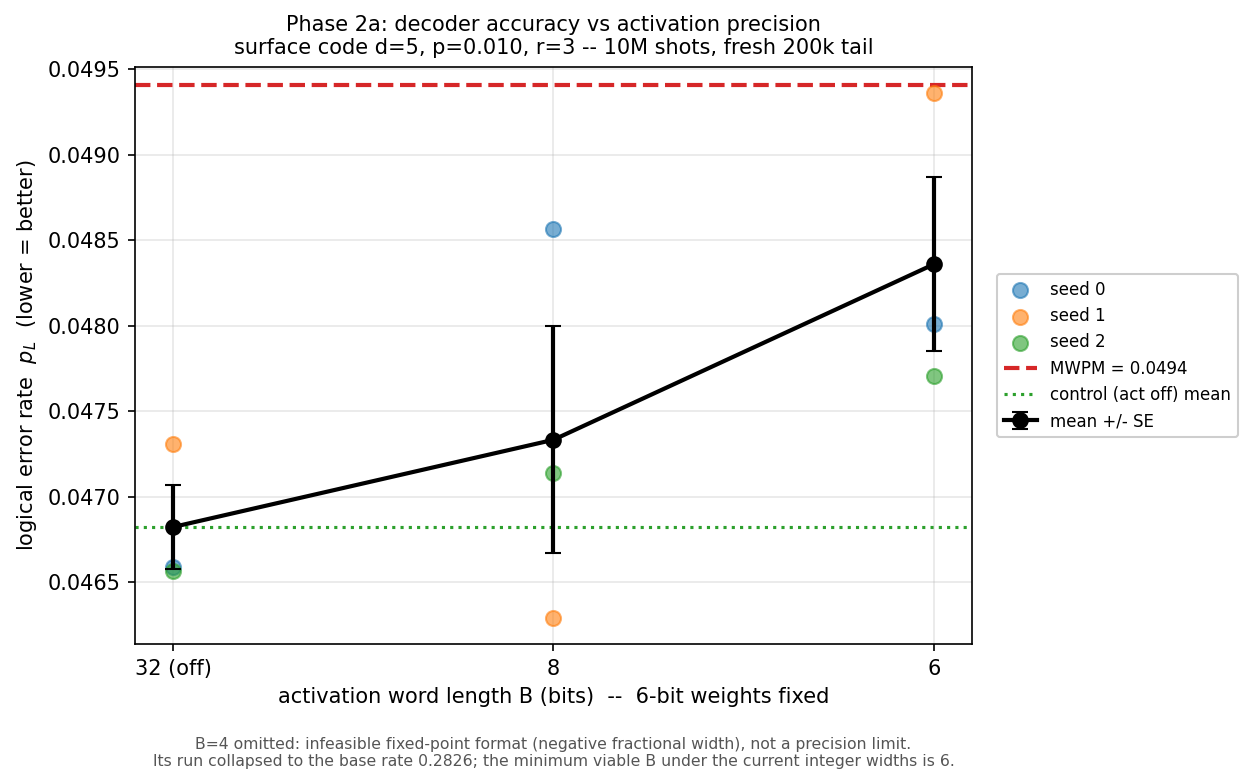

In [12]:
# The figure. B=4 is excluded by default (--plot-exclude-bits): at 0.2826 it is ~6x every other
# point, which flattens the 0.046-0.050 band where the result actually lives and reads as "4-bit
# fails" -- the one conclusion the data does not support. The figure states the omission on itself.
from IPython.display import Image
p = 'plots/phase2a_activation_sweep.png'
if not os.path.exists(p):
    print('regenerate with:  python phase2a_collate.py --dir', OUT_2A)
Image(p) if os.path.exists(p) else None

### Where this leaves the FPGA path

1. **Activation quantization works.** Bounded tensors at 8 bits cost nothing systematic; 6 bits
   cost a small consistent +0.0015 and are marginal against MWPM on one seed.
2. **B=4 is not a measurement** — it is a floor imposed by the architecture's own clip bounds
   (z-like ±12 → I=4), now rejected up front by a guard rather than burning a multi-hour run.
3. **This is still not a synthesizable model.** The **x-like** tensors remain FP32 throughout:
   every `CNNKernelWithEmbedding` / `CNNStateCorrelator` output has `frac@B6 < 0` with implied
   I up to 17 (correlator #2, seed 1: max 1.2e5 — ~10 decades). No `ap_fixed` at any sane width.

That last point is Phase 4, and the **phase-matrix result above is why it is hard**, not merely
tedious: the n=3 recurrence correlators have an indefinite phase matrix ~95% of the time, so the
log-domain combination genuinely goes ≤0 and *plain* LSE is unavailable. The remedy is a **choice**
(signed-LSE, or constrain c_φ to PSD via a Gram parameterization and retrain, which may cost
accuracy since the model is actively using the indefinite region) — and it is **not decided**.

**Open:**
- ~~Rerun B=6 with the p99.9 ReLU width to test whether the +0.0015 is the zero-fractional-width
  ReLU.~~ **Done — see Phase 2a-ReLU below. Hypothesis rejected.**
- A genuine low-B datapoint needs the integer-width policy retuned; B=4 stays blocked by z-like.
- Phase 4 owns the x-like tensors. Decide signed-LSE vs Gram-constrained c_φ **with the collaborator**.

## Phase 2a-ReLU — decoder-ReLU width retune at B=6 (negative result)

**Hypothesis.** The approximately +0.0015 logical-error-rate cost at activation B=6 was caused
primarily by the decoder ReLU having zero fractional bits under the abs-max format I=6, F=0.

**Test.** Retrained the B=6 models for seeds 0, 1, and 2 with the shared ReLU integer width reduced
to I=5, giving F=1, while leaving all other training and quantization settings unchanged.

**Result.** The mean cost relative to each seed's act32 control changed from +0.00154 to +0.00176.
Individual seeds moved in mixed directions, with no consistent improvement.

**Conclusion.** No improvement from the ReLU retune was detectable above run-to-run variation. The
zero-fractional-width ReLU is therefore not supported as the dominant cause of the B=6 degradation.
Because I=5 provided no observed benefit and reduced representable range, the safer I=6 format is
retained. The specific activation class or site responsible for the B=6 cost remains unidentified.
Effects smaller than approximately 1e-3 cannot be resolved reliably with the current independent
n=3 design.

saved -> figures/phase2a_relu_retune.png
abs-max deltas: [0.00142, 0.00205, 0.00114]  mean +0.00154
retuned deltas: [0.0033, 0.00069, 0.00128]  mean +0.00175


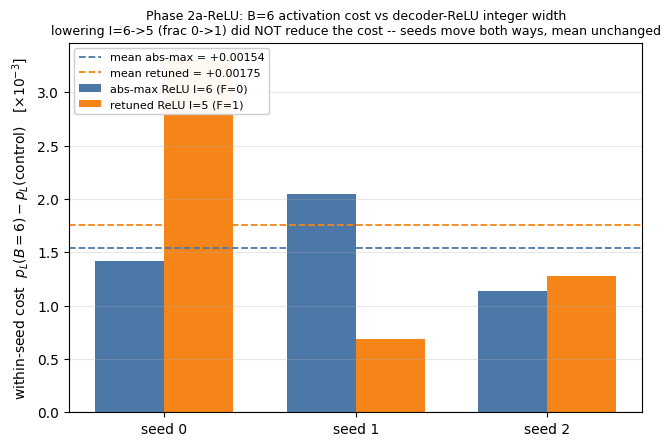

In [13]:
# Phase 2a-ReLU: compare the within-seed B=6 cost under the two ReLU integer widths.
# Live -- loads both result dirs from disk. abs-max I=6 lives in out_q_phase2a; retuned I=5 in
# out_q_phase2a_relu5 (its a32 controls were copied in, so each dir differences against its own).
import matplotlib.pyplot as plt

OUT_2A_RELU5 = os.path.join(BASE, 'out_q_phase2a_relu5')

def _pl(d):
    """{(act_bits, seed): p_L} from the 10M CSVs in dir d."""
    out = {}
    for f in glob.glob(os.path.join(d, '*_ntr10000000.csv')):
        r = pd.read_csv(f).iloc[0]
        out[(int(r['act_bits']), int(r['seed']))] = float(r['p_L'])
    return out

absmax = _pl(OUT_2A)          # relu I=6 (abs-max)   -- primary sweep
retune = _pl(OUT_2A_RELU5)    # relu I=5 (profiled)  -- retune
seeds = [0, 1, 2]

# within-seed cost = p_L(B=6) - p_L(that seed's own act32 control)
d_abs = [absmax[(6, s)] - absmax[(32, s)] for s in seeds]
d_ret = [retune[(6, s)] - retune[(32, s)] for s in seeds]
m_abs, m_ret = np.mean(d_abs), np.mean(d_ret)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
x = np.arange(len(seeds)); w = 0.36
ax.bar(x - w/2, np.array(d_abs)*1e3, w, label='abs-max ReLU I=6 (F=0)', color='#4C78A8')
ax.bar(x + w/2, np.array(d_ret)*1e3, w, label='retuned ReLU I=5 (F=1)', color='#F58518')
# mean lines (in the same 1e-3 units)
ax.axhline(m_abs*1e3, color='#4C78A8', ls='--', lw=1.3, label=f'mean abs-max = {m_abs:+.5f}')
ax.axhline(m_ret*1e3, color='#F58518', ls='--', lw=1.3, label=f'mean retuned = {m_ret:+.5f}')
ax.axhline(0, color='0.4', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([f'seed {s}' for s in seeds])
ax.set_ylabel(r'within-seed cost  $p_L(B{=}6) - p_L(\mathrm{control})$   [$\times10^{-3}$]')
ax.set_title('Phase 2a-ReLU: B=6 activation cost vs decoder-ReLU integer width\n'
             'lowering I=6->5 (frac 0->1) did NOT reduce the cost -- seeds move both ways, '
             'mean unchanged', fontsize=9)
ax.legend(fontsize=8, loc='upper left', framealpha=0.95)
ax.grid(axis='y', alpha=0.3)
os.makedirs('figures', exist_ok=True)
out_png = 'figures/phase2a_relu_retune.png'
fig.savefig(out_png, dpi=150, bbox_inches='tight')
print('saved ->', out_png)
print(f'abs-max deltas: {[round(v,5) for v in d_abs]}  mean {m_abs:+.5f}')
print(f'retuned deltas: {[round(v,5) for v in d_ret]}  mean {m_ret:+.5f}')
plt.show()

## Provenance & status

- **Ledger:** `docs/RUN_LOG.md` (fixed substrate + every phase + git SHAs).
- **Branch:** `quantization-pareto` (local only — not pushed; RCNN repo reorg pending).
- **Files:** `CNNModel_quantized.py`, `train_one_quantized.py`, `sweep_quantized.py`,
  `collate_pareto.py`, `make_fresh_tail.py`, `eval_on_tail.py`, `phase1_mcnemar.py`,
  `profile_ranges.py`, `phase2a_sweep.py`, `phase2a_collate.py`, `phase2a_mcnemar.py`,
  `docs/RUN_LOG.md`, this notebook + `build_quant_notebook.py`.

**Open:** Phase 0–3 and Phase 2a are DONE. Next: rerun B=6 with the p99.9 ReLU width
(`ActQuant.set_relu_integer(4)`), then Phase 4 (log-domain / LSE) for the x-like tensors —
which needs the signed-LSE vs Gram-constrained-c_φ decision made with the collaborator.

In [14]:
# git provenance for this work (run on the machine with the repo)
# !git log --oneline -20 -- CNNModel_quantized.py train_one_quantized.py sweep_quantized.py \
#     collate_pareto.py make_fresh_tail.py eval_on_tail.py phase1_mcnemar.py profile_ranges.py
print('see docs/RUN_LOG.md and: git log --oneline quantization-pareto')

see docs/RUN_LOG.md and: git log --oneline quantization-pareto
